<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Optimizers in Gradient Descent**


## **Introduction**
Optimizers are algorithms that update a neural network's weights to minimize the loss function. They have evolved over time to solve specific issues like slow training, getting stuck in local minima, or dealing with sparse data.

To understand how a neural network optimizes its weights, imagine a ball rolling down a rugged mountain landscape trying to find the lowest valley (**Global Minimum**).

**1. Gradient Descent (The Gravity)**: The core optimization algorithm.
* **Physics Analogy:** **Gravity**. 
* **Role:** It looks at the slope of the hill at the ball's current position and determines which direction is "downhill." It is the force that tells the model *where* it needs to go to reduce error.

**2. Learning Rate (The Speed / Step Size)**: The hyperparameter $\alpha$ that scales the gradient update
* **Physics Analogy:** **Base Velocity (Speed)**.
* **Role:** It dictates how far the ball travels in a single step. 
  * *Too high:* The ball moves too fast, leaps across valleys, and flies off the mountain (**diverges**).
  * *Too low:* The ball crawls at a snail's pace, making training incredibly slow.

**3. Momentum (The Acceleration / Inertia)**: The hyperparameter $\beta$ that factors in past gradients.
* **Physics Analogy:** **Acceleration and Inertia**.
* **Role:** It accumulates the ball's past speed. If the ball keeps rolling in the same direction, it **accelerates** and gains momentum. This kinetic energy allows the ball to easily roll over small bumps (**local minima**) or slide across flat areas (**plateaus**) where standard gravity alone would cause it to stall.


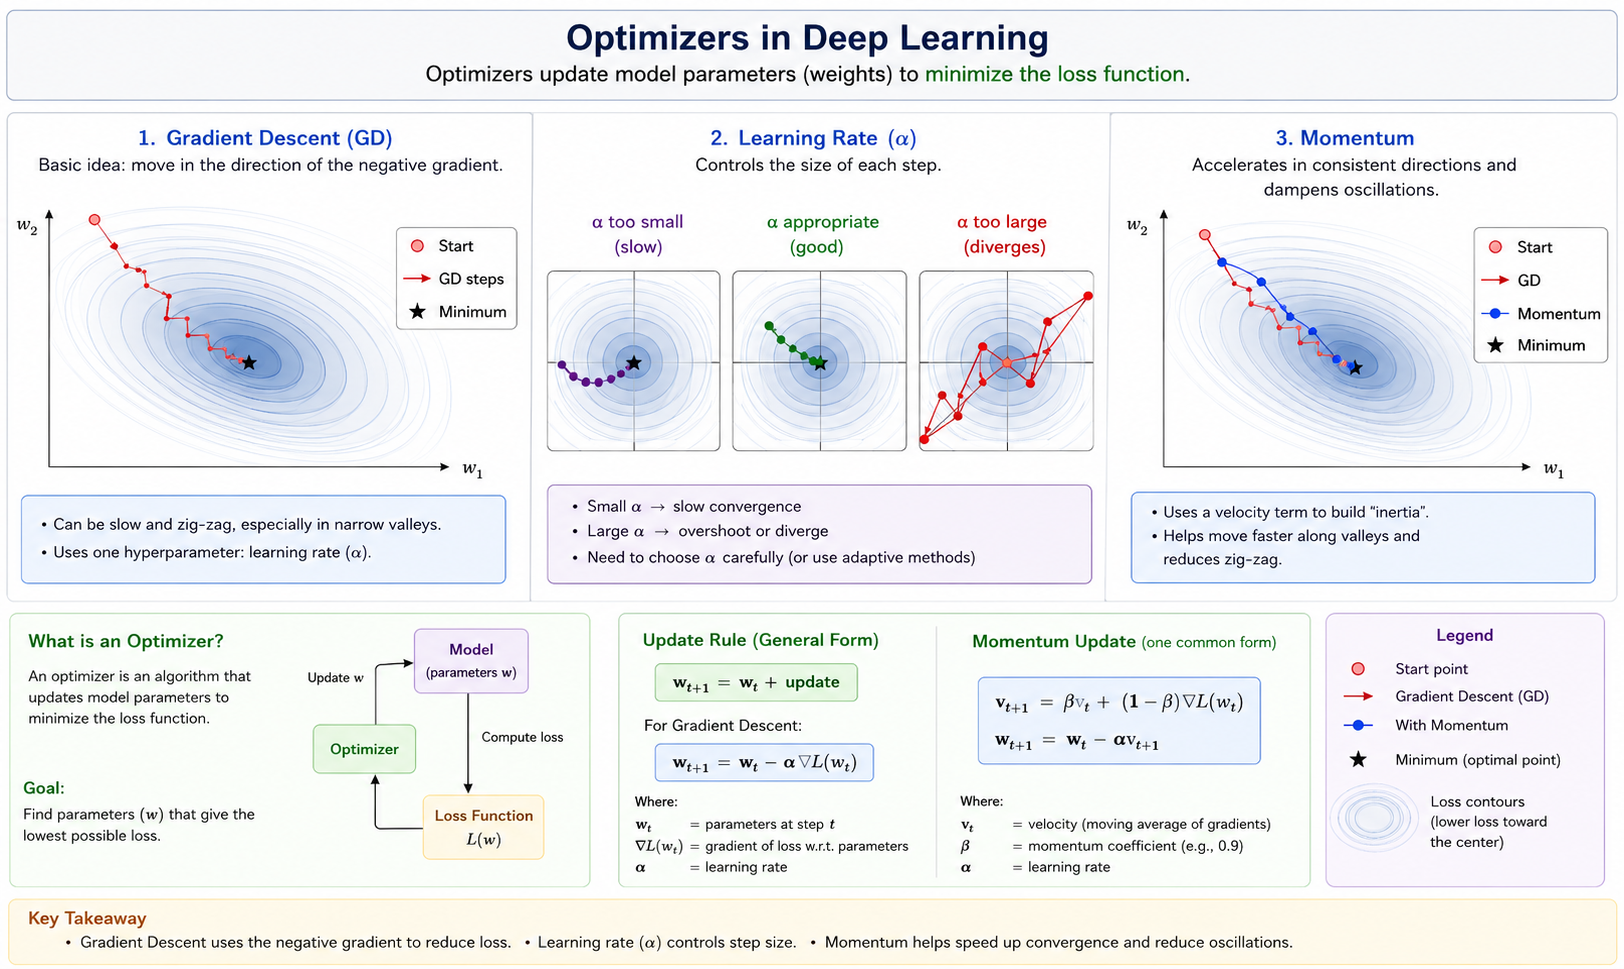

### **Mathematical Interaction**

To see how these concepts interact, we can look at how they mathematically construct the weight update during training.

**1. Standard Gradient Descent**
Without momentum, the step size is purely a product of the current slope (Gradient) and your base speed (Learning Rate $\alpha$):

$$\text{Step} = \alpha \times \text{Gradient}$$

$$\text{Weight}_{\text{new}} = \text{Weight}_{\text{old}} - \text{Step}$$

* **The Problem:** If the `Gradient` drops to $0$ (a flat plateau), the `Step` becomes $0$, and learning completely stops.

**2. Gradient Descent with Momentum**
Momentum introduces a velocity vector ($v$) that tracks historical speed and direction, adding an **acceleration** effect:

$$v_{\text{new}} = (\beta \times v_{\text{old}}) + (\alpha \times \text{Gradient})$$

$$\text{Weight}_{\text{new}} = \text{Weight}_{\text{old}} - v_{\text{new}}$$

Breaking Down the Interaction:

* **$\alpha \times \text{Gradient}$ (The Immediate Push):** The current slope acts as the instantaneous gravitational force, scaled by the learning rate to dictate the immediate change in velocity.
* **$\beta \times v_{\text{old}}$ (The Accumulated Inertia):** The momentum coefficient ($\beta$, usually `0.9`) retains 90% of the previous step's velocity. 
* **The Acceleration Effect:** If the current `Gradient` points in the same direction as $v_{\text{old}}$, the two terms add together, causing $v_{\text{new}}$ to grow larger with each step. This is **acceleration**.
* **Overcoming Obstacles:** If the model hits a flat plateau where the `Gradient` becomes $0$, the equation simplifies to:
  $$v_{\text{new}} = \beta \times v_{\text{old}}$$
  Because of momentum, the velocity does not immediately drop to zero. The ball uses its **inertia** to keep rolling across the flat zone.


Here is the breakdown of the major types of optimizers, grouped by how they compute updates.

## **Gradient Descent Family** 
The simplest optimizers are based on Gradient Descent. They mainly differ in how much training data is used before each weight update.

**Batch Gradient Descent:**
Batch Gradient Descent computes gradients using the entire dataset before updating the weights. This approach is stable and accurate, but it becomes very slow for large datasets because every update requires processing all samples.

**Stochastic Gradient Descent (SGD):**
SGD updates the weights using only one training sample at a time. It is computationally fast, but the updates are noisy and unstable because each sample may point in a slightly different direction.

**Mini-Batch Gradient Descent:**
Mini-batch Gradient Descent is the modern standard approach. Instead of using the whole dataset or a single sample, it processes small batches such as 32 or 64 samples at a time. This provides a good balance between speed and stability.

```python
model.fit(
    x_train,
    y_train,
    batch_size=1
)
```
| Method                 | batch_size  (from model.fit())                   |
| ---------------------- | ------------------------------ |
| Batch Gradient Descent | entire dataset                 |
| Mini-batch SGD         | small batch (e.g. 32, 64, 128) |
| True SGD               | 1                              |



Then how to improve its performance, in this lab, you will see different optimizers could also play a big role in neural network training process.



## **Momentum-Based Optimizers** 
Standard SGD can move slowly when the loss surface contains narrow valleys or flat regions. Momentum-based optimizers improve this by remembering previous updates.

**SGD with Momentum:**
Momentum accumulates past gradients and builds velocity in directions that consistently reduce the loss. This helps suppress oscillations and speeds up convergence.

**Nesterov Accelerated Gradient (NAG):**
NAG is a modified version of momentum. Instead of calculating gradients only at the current position, it estimates where the optimizer will move next and computes the gradient there. This often improves stability and reduces overshooting.

## **Adaptive Learning Rate Optimizers**
Instead of using one fixed learning rate for all parameters, adaptive optimizers automatically adjust the learning rate for each weight individually.

**Adagrad:**
Adagrad increases updates for infrequent parameters and decreases updates for frequently updated parameters. This works well for sparse data such as text features. However, the learning rate may shrink too much over time, causing training to stop prematurely.

**RMSprop:**
RMSprop improves Adagrad by preventing the learning rate from decaying too aggressively. It uses an exponentially weighted moving average of past squared gradients, allowing the learning rate to adapt dynamically during training.

**Adam(Adaptive Moment Estimation):**
Adam is one of the most widely used optimizers in deep learning. It combines two important ideas:
- Momentum, which tracks past gradients
- RMSprop, which tracks past squared gradients

As a result, Adam is usually fast, stable, and performs well across many different neural network architectures.

**AdamW:**
AdamW is a modified version of Adam that improves weight decay (L2 regularization). Instead of mixing regularization into the gradient calculation, AdamW applies weight decay directly to the weights. This produces better generalization and has become the standard optimizer for many modern Transformer and Large Language Model (LLM) architectures.

## **Objectives**


After completing this lab you will be able to:


* Explain several popular optimizers
* Evaluate their performance in a real-world classification scenario
* (Optional)Implement adam optimizer from scrach


## **Prepare and setup the lab environment**


At the beginning, we need to install one required Python packages.


In [40]:
# %%capture
#!pip install --upgrade tensorflow

and import necessary class/methods in the packages


In [41]:
import pandas as pd
import numpy as np
import time
import sys

import warnings
warnings.simplefilter('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn import metrics
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import keras
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, RMSprop, Adam, Adagrad
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


### **Load and explore the dataset**


In [42]:
food_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/food_items.csv"
)

In [43]:
food_df.head()

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron,class
0,149.0,0,0.0,0.0,0.0,0.0,0,9.0,9.8,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
1,123.0,0,0.0,0.0,0.0,0.0,0,5.0,6.6,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
2,150.0,0,0.0,0.0,0.0,0.0,0,4.0,11.4,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
3,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
4,143.0,0,0.0,0.0,0.0,0.0,0,7.0,13.1,0.0,0.0,0,1.0,0,0,0,0,'In Moderation'


Let's quickly take a look at the dataset:


In [44]:
food_df.shape

(13260, 18)

As we can see, it has 13260 data instances and 18 columns (features + label):


In [45]:
food_df.dtypes

Calories               float64
Total Fat                int64
Saturated Fat          float64
Monounsaturated Fat    float64
Polyunsaturated Fat    float64
Trans Fat              float64
Cholesterol              int64
Sodium                 float64
Total Carbohydrate     float64
Dietary Fiber          float64
Sugars                 float64
Sugar Alcohol            int64
Protein                float64
Vitamin A                int64
Vitamin C                int64
Calcium                  int64
Iron                     int64
class                   object
dtype: object

More features are about the nutritions of a specific food items. Then let's check the target variable, i.e., the `class` column:


In [46]:
# # Get the row entries with the last col 'class'
food_df.iloc[:, -1:].value_counts(normalize=True)

class          
'In Moderation'    0.501433
'Less Often'       0.423906
'More Often'       0.074661
Name: proportion, dtype: float64

<Axes: xlabel='class'>

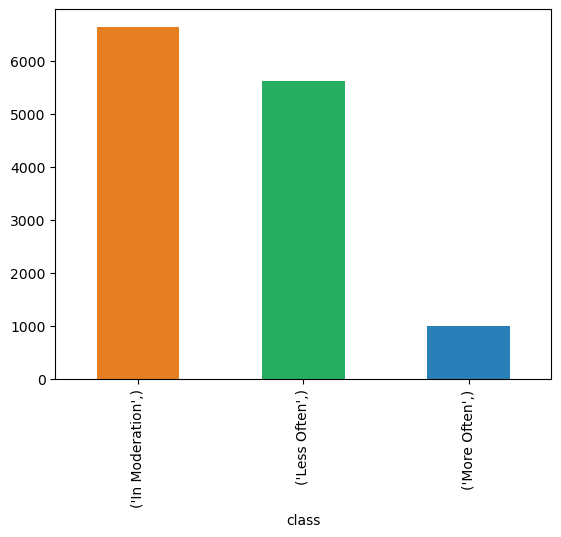

In [47]:
# # Get the row entries with the last col 'class'
food_df.iloc[:, -1:].value_counts().plot.bar(
    color=["#e67e22", "#27ae60", "#2980b9"]
)

The target variable indicates how often we should include this food item in our diet, and it has three classes `In Moderation`, `Less Often`, `More Often`. It indicates that this is a multi-class classification task and the class distribution is a little bit imbalanced.


## **Data processing**


First split the features `X` (the input) and labels `y` (the output)


In [48]:
X_raw = food_df.iloc[:, :-1]
y_raw = food_df.iloc[:, -1:]

Then normalize the `X`:


In [49]:
# Create a MinMaxScaler object
scaler = MinMaxScaler()
# Scaling the raw input features
X = scaler.fit_transform(X_raw)

and encode the target variable:


In [50]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw.values.ravel())

Finally we can split the dataset into training and testing datasets, and we're ready to train a neural network.


In [51]:
rs = 123  # set random state

In [52]:
# First, let's split the training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=rs
)
print(
    f"Training dataset shape, X_train: {X_train.shape}, y_train: {y_train.shape}"
)
print(f"Testing dataset shape, X_test: {X_test.shape}, y_test: {y_test.shape}")

Training dataset shape, X_train: (10608, 17), y_train: (10608,)
Testing dataset shape, X_test: (2652, 17), y_test: (2652,)


## **Train a Neural Network with SGD (Stochastic Gradient Descent)**


As the initial model, we plan to train a basic multilayer perceptron neural network with the following settings:
- Two hidden layers with shapes `(17, 32)` and `(32, 8)`. Note the number `17` represents the dimension of the feature vector X. You may try different hidden layers setting as well.
- Set the solver/optimizer to be SGD
- Disable momentum
- Enable early stopping


In [53]:
base_ann = MLPClassifier(
    random_state=rs,
    hidden_layer_sizes=(32, 8),
    solver="sgd",
    momentum=0,
    early_stopping=True,
    max_iter=100,
)

As you may recall, the formula for SGD is using the gradient calculated from instance `i` only:


$$W_t := W_{t-1} - \alpha \nabla_iJ$$


Then we may use the following helper function to quickly train the neural network and report its training and test score.


In [54]:
def fit_and_score(model, X_train, X_test, y_train, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    n_iter = model.n_iter_
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    loss_curve = model.loss_curve_
    return round(fit_time, 2), n_iter, train_score, test_score

In [55]:
fit_time, n_iter, train_score, test_score = fit_and_score(
    base_ann, X_train, X_test, y_train, y_test
)

In [56]:
print(
    f"Training converged after {n_iter} iterations with train score (accuracy) {round(train_score, 2)} \
and test score (accuracy) {round(test_score, 2)}."
)

Training converged after 12 iterations with train score (accuracy) 0.42 and test score (accuracy) 0.42.


As we can see from above cell output, a classification task with accuracy around `40%` is definitly unacceptable. But how is it even possible as we are using a Neural Network to do the task!


Such bad train and test score is normally considered as underfitting which actually happends very often in training neural networks which is normally more complex than shallow models. The reasons could be too simple network architecture, insufficient training data or iterations, trapped in local minima, etc.


For our case, it could be the bad quality or low predictability of our dataset. To verify that, let's try to build a simple logistic regression to see if it can perform the task well.


In [57]:
# Define a logistic regression model with above arguments
lr_model = LogisticRegression(random_state=rs, max_iter=200)
lr_model.fit(X_train, y_train)
lr_score = lr_model.score(X_test, y_test)
print(f"The test score for the logistic regression is {round(lr_score, 2)}")

The test score for the logistic regression is 0.77


Now we can see a logistic linear regression can get around 0.75 accuracy which is much better than the neural network. We can see our dataset is pretty predictable. We must have done something improperly in the neural network training.


One common reason is that the SGD was trapped in one of the local minima. Let's illusrate this idea in the following simple example:


First we define a helper function to draw some cost functions.


In [58]:
def draw_cost(X, Y, Z, title):
    fig = plt.figure()
    fig.set_size_inches(8, 6, forward=True)
    fig.set_dpi(100)
    ax = plt.axes(projection="3d")
    ax.view_init(30, 35)
    ax.contour3D(X, Y, Z, 100, cmap=plt.cm.coolwarm)
    ax.set_title(title)

Ideally, a cost function only has one global minima and SGD can find it.


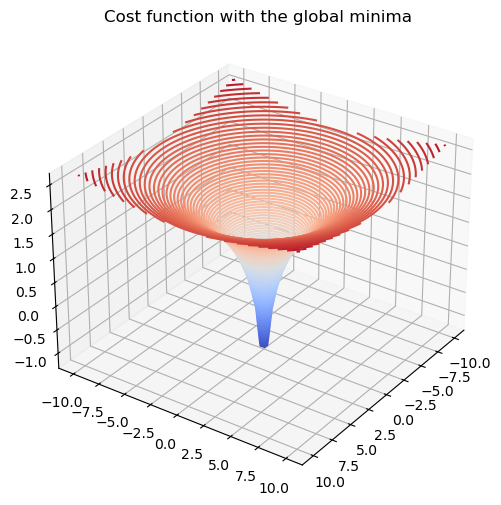

In [59]:
def one_mini_function():
    w1 = np.linspace(-10, 10, 50)
    w2 = np.linspace(-10, 10, 50)
    X, Y = np.meshgrid(w1, w2)
    Z = np.log(np.sqrt(X**2 + Y**2))
    return X, Y, Z


X, Y, Z = one_mini_function()
draw_cost(X, Y, Z, "Cost function with the global minima")

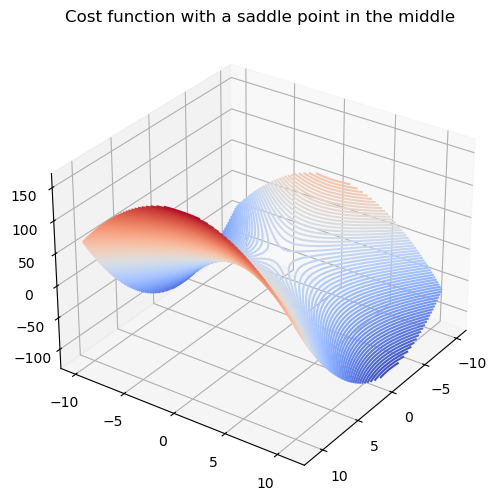

In [60]:
def multi_mini_function():
    w1 = np.linspace(-10, 11, 50)
    w2 = np.linspace(-10, 11, 50)
    X, Y = np.meshgrid(w1, w2)
    Z = X**2 - Y**2 + 4 * X
    return X, Y, Z


X1, Y1, Z1 = multi_mini_function()
draw_cost(X1, Y1, Z1, "Cost function with a saddle point in the middle")

However, if the cost function has multiple minima or even saddle points (where gradients are very small or zeros so the weights won't be updated), the SGD may be stuck at the local minima. For example, the following cost function has a saddle point at `(0, 0)` in the middle which could stop the gradients from further going down, as shown in the following picture:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/saddle.png)


As a result, the total loss won't be reduced and the model would perform badly in the classification task. To tackle this local minima challenge, we could either try to add some noises in SGD or randomly switch the starting point. Furthermore, we may also utilize momentum to make gradient jump out of local minima or saddle points.


## **Retrain the Neural Network with momentum**


With the regular SGD, the weights are generally moving slowly towards to a optimum (can be a local one like the previous example). Now, with momentum, you're going to smooth out this process. You can do this by taking somewhat of a running average of each of the steps and then smoothing out that variation of each of the individual steps for regular gradient descent.


$$v_t := \eta v_{t-1} + \alpha \nabla J$$


$$W_t := W_{t-1}  - v_t$$


We can see that rather than just simply updating our weights with that gradient, we also look back to prior values $v_{t-1}$ to smooth out these steps. So this is at the step $t$ that we have, which will incorporate some amount of $v_{t-1}$ at step $t-1$. 


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/momentum.png)


* **$W_{t-1}$ to $V_{t-1}$:** This represents the **historical direction and inertia** you were already traveling from previous iterations.
* **$\nabla J$ (The Gradient):** This is the **current downhill slope** trying to steer you in a new direction based strictly on your local position.
* **$W_t$ with SGD:** Without momentum, you ignore past trajectory. You would start at the end of $W_{t-1}$ and follow the $\nabla J$ arrow straight up. This steep, sudden shift in direction is what causes regular SGD to bounce around wildly.
* **$V_t$ and $W_t$ with Momentum:** With momentum active, you combine your previous velocity ($V_{t-1}$) and the current gradient ($\nabla J$). The grey line ($V_t$) is the resultant vector of adding those two forces together, leading to the green line (**$W_t$ with momentum**). This creates a smoother, faster, and more consistent trajectory.

As a summary, adding momentum in weights update may bring the following benefits:
1. Smooth the weight updating process by incorporating previous direction
2. Tend to generate larger and consistent steps which may tackle the saddle points problem


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/jumpout.png)


Let's retrain our neural network with momentum. With `MLPClassifier` class, you just need to give a positive momentum value such as 0.9.


In [61]:
momentum_ann = MLPClassifier(
    random_state=123,
    hidden_layer_sizes=(32, 8),
    solver="sgd",
    momentum=0.9,
    early_stopping=True,
    max_iter=100,
)
fit_time, n_iter, train_score, test_score = fit_and_score(
    momentum_ann, X_train, X_test, y_train, y_test
)
print(
    f"Training converged after {n_iter} iterations with test score (accuracy) {round(test_score, 2)}"
)

Training converged after 93 iterations with test score (accuracy) 0.73


Now, as you can see with momentum added in SGD process, our performance gets much better from 0.42 to 0.73. 


### **Exercise: Retrain the Neural Network with Nesterov’s momentum**


However, sometimes adding momentum may overshoot the minima and make the training process longer. So we may add Nesterov’s momentum to further improve training process.


To use Nesterov’s momentum, you just need to to set argument `nesterovs_momentum=True` in `MLPClassifier` class.`


In [62]:
# Write your code here
nesterovs_ann = MLPClassifier(
    random_state=123,
    hidden_layer_sizes=(32, 8),
    solver="sgd",
    momentum=0.95,
    nesterovs_momentum=True,
    early_stopping=True,
    max_iter=100,
)
fit_time, n_iter, train_score, test_score = fit_and_score(
    nesterovs_ann, X_train, X_test, y_train, y_test
)
print(
    f"Training converged after {n_iter} iterations with score (accuracy) {round(test_score, 2)}"
)

Training converged after 83 iterations with score (accuracy) 0.74


## **Adam Optimizer**


For efficient training, sometimes we may want the learning rates to be adaptive, i.e., large learning rate at the beginning and gets decaying over time. Adam combines the concepts of momentum we have seen previously and gradient decaying over time. As such, it could take very smooth steps and avoid overshooting the optima.


Adam is designed to improve the training process, it may either:
- Decrease number of training iterations 
- Improve the model performance by finding a better or global optima


### **Exercise: Retrain the Neural Network with Adam optimizer**


To use Adam in `MLPClassifier` is also very simple, you just need to change the solver to be 'adam' (which is actually the default setting).


In [63]:
# Write your code here
adam_ann = MLPClassifier(
    random_state=123,
    hidden_layer_sizes=(32, 8),
    solver="adam",
    early_stopping=True,
    max_iter=100,
)
fit_time, n_iter, train_score, test_score = fit_and_score(
    adam_ann, X_train, X_test, y_train, y_test
)
print(
    f"Training converged after {n_iter} iterations with score (accuracy) {round(test_score, 2)}"
)

Training converged after 73 iterations with score (accuracy) 0.84


<details>
    <summary>Click here for a Solution</summary>

```python
adam_ann = MLPClassifier(random_state=123,  hidden_layer_sizes=(32, 8), 
                    solver='adam',
                    early_stopping=True,
                    max_iter=100)
fit_time, n_iter, train_score, test_score = fit_and_score(adam_ann, X_train, X_test, y_train, y_test)
print(f"Training converged after {n_iter} iterations with score (accuracy) {round(test_score, 2)}")
```

</details>


You should see that Adam has the smallest iterations but best performance. 


If you are interested in how Adam is implemented, you may refer to the following optional section.


## **Optional: Implement Adam optimizer from scrach**
Adam is one of the most widely used optimizers in deep learning.
The purpose of an optimizer is to update the model weights so that the loss function becomes smaller during training.

### **Step 1 — Standard Gradient Descent**

Standard Gradient Descent updates the weights using only the current gradient:
$$
Step = \alpha \times Gradient
$$
$$
Weight_{new} = Weight_{old} - Step
$$
$$
Weight_{new} = Weight_{old} - \alpha \times Gradient
$$
where:

- $\alpha$ is the learning rate
- The gradient tells us the slope of the loss function at a given point and shows which direction increases the loss.

To minimize the loss, we move in the opposite direction. For example:
- positive gradient → decrease the $Weight_{new}$ value
- negative gradient → increase the $Weight_{new}$ value
- large gradient → the weight changes by a large amount in one step
- small gradient → the weight changes by a small amount in one step

The problem is that standard Gradient Descent can become unstable:
- updates may oscillate
- movement may become noisy
- learning may become slow on flat regions

### **Step 2 — Gradient Descent with Momentum**

Momentum introduces memory: instead of using only the current gradient, momentum remembers previous movement direction. The update becomes: 

$$m_{new}=(\beta_1 \times m_{old})+((1-\beta_1)\times Gradient)$$

Then the weight update becomes:$$Weight_{new}=Weight_{old}-(\alpha \times m_{new})$$
Here:

- $m_{new}$ is the smoothed movement direction
- $\beta_1$ controls how much previous movement is remembered
- $\alpha$ is still the learning rate

Typical value: $\beta_1 = 0.9$ This means Momentum remembers about 90% of the previous direction.
The purpose of Momentum is to remember the overall movement direction, instead of reacting only to the newest gradient.

### **Step 3 — The Remaining Problem with Momentum**

**Momentum Can Create Large Updates Over Time**

At first, it may seem that Momentum does not amplify updates.

For example:
$$update = \alpha \times gradient$$

Suppose:
$$\alpha = 0.1$$
$$gradient = 100$$

Then plain Gradient Descent gives:
$$update = 0.1 \times 100 = 10$$

Now consider Momentum. The Momentum equation is:
$$m_{new}=\beta m_{old}+(1-\beta)gradient$$

Suppose:
$$m_{old} = 80$$
$$gradient = 100$$
$$\beta = 0.9$$

Then the calculation unfolds as follows:
$$
\begin{aligned}
m_{new} &= 0.9 \times 80 + 0.1 \times 100 \\
&= 72 + 10 \\
&= 82
\end{aligned}
$$

The final update becomes:
$$update = 0.1 \times 82 = 8.2$$

This is actually **smaller** than the update of $10$ from plain Gradient Descent. So in this single-step example, Momentum did NOT amplify the update.

**Accumulation Over Time**

However, suppose the gradients remain consistently large over multiple consecutive steps: $100, 100, 100, 100 \dots$
Now Momentum keeps building velocity over time.

Let parameters be: $\beta = 0.9$, $\alpha = 0.1$, and start with $m_0 = 0$.

* **Step 1:**
  $$m_1 = 0.9 \times 0 + 0.1 \times 100 = 10$$
  $$update = 0.1 \times 10 = 1$$

* **Step 2:**
  $$m_2 = 0.9 \times 10 + 0.1 \times 100 = 9 + 10 = 19$$
  $$update = 0.1 \times 19 = 1.9$$

* **Step 3:**
  $$m_3 = 0.9 \times 19 + 0.1 \times 100 = 17.1 + 10 = 27.1$$
  $$update = 0.1 \times 27.1 = 2.71$$

* **Step 4:**
  $$m_4 = 0.9 \times 27.1 + 0.1 \times 100 = 24.39 + 10 = 34.39$$
  $$update = 0.1 \times 34.39 = 3.439$$

Notice how the actual step sizes keep growing sequentially:
$$1 \rightarrow 1.9 \rightarrow 2.71 \rightarrow 3.439$$

Because Momentum continuously accumulates movement in the same directional path, it can create an excessively aggressive acceleration over time.

### **Step 4 — Adam Adds a Second Moving Average**

Adam computes another moving average: 
$$s_{new} =
(\beta_2 \times s_{old})
+
((1-\beta_2)\times Gradient^2)
$$

The final update becomes: $$Weight_{new}=Weight_{old}-\frac{\alpha \times m_{new}}{\sqrt{s_{new}}+\epsilon}$$

where:

- $\alpha$ is still the learning rate
- $m_{new}$ controls movement direction
- $\sqrt{s_{new}}$ scales the update size
- $\epsilon$ is a tiny value to avoid division by zero. Typical value: $\epsilon = 10^{-8}$

The numerator:  $\alpha \times m_{new}$
controls the movement direction.
This is very similar to Momentum.
The denominator: $\sqrt{s_{new}}$
controls update size.

If gradients become huge:  $s_{new}$ becomes huge, then: $\frac{1}{\sqrt{s_t}}$ becomes very small.
So the overall update becomes smaller. This is the key idea of Adam.


### **Step 5 — Bias Correction**

At the beginning of training: There is very little historical information, so the moving averages are artificially too small.
$m_0 = 0$
$s_0 = 0$

Adam corrects this using:

$$
\hat{m}_t =
\frac{m_t}{1-\beta_1^t}
$$

$$
\hat{s}_t =
\frac{s_t}{1-\beta_2^t}
$$

Bias correction compensates for this early underestimation. As training continues:
$\beta_1^t \rightarrow 0$  $\beta_2^t \rightarrow 0$. 

The correction gradually becomes negligible. After bias correction, the final Adam update becomes 
$$Weight_{new}=Weight_{old}-
\frac{\alpha \times \hat{m}_t}
{\sqrt{\hat{s}_t}+\epsilon}$$




To demonstrate Adam, we can use:

$$
J = (w-4)^2 + 2w
$$

Its gradient is:

$$
\nabla J = 2(w-4)+2
$$



In [64]:
# cost function
def cost_function(w):
    return (w - 4) ** 2 + 2 * w


## take derivative
def grad_function(w):
    return 2 * (w - 4) + 2

Let's plot this cost function with the following helper function.


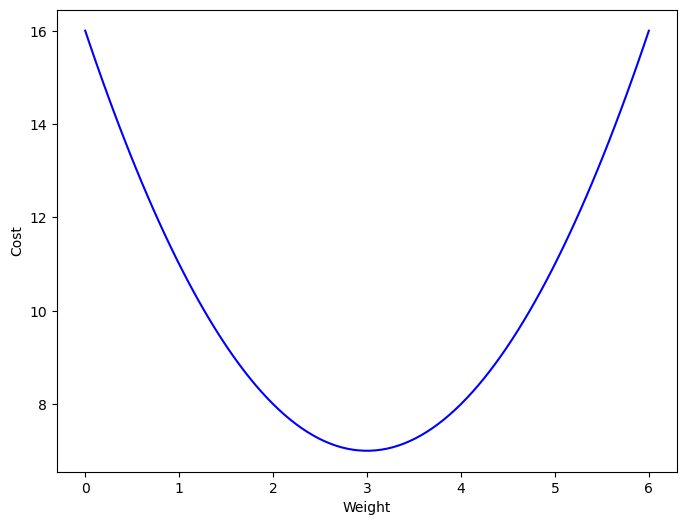

In [65]:
def plot_cost():
    fig, axis = plt.subplots()
    fig.set_size_inches(8, 6, forward=True)
    fig.set_dpi(100)

    x = np.linspace(0, 6, 100)
    y = cost_function(x)
    axis.plot(x, y, "b")
    axis.set_xlabel("Weight")
    axis.set_ylabel("Cost")


plot_cost()

In [66]:
def is_converged(w0, w1):
    return abs(w0 - w1) <= 1e-6


# Implement Adam
def adam(t, w, dw, m, v, alpha=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8):
    # para
    # First-moment
    m = beta1 * m + (1 - beta1) * dw
    # Second-moment
    v = beta2 * v + (1 - beta2) * (dw**2)
    # Bias correction
    m_unbiased = m / (1 - beta1**t)
    v_unbiased = v / (1 - beta2**t)
    # Update weights
    w = w - alpha * (m_unbiased / (np.sqrt(v_unbiased) + epsilon))
    return w, m, v

Next, we could use the gradients and Adam to optimize the cost function:


In [67]:
w, m, v, t = 0, 0, 0, 1
converged = False
w_his = []
loss_his = []
while not converged:
    dw = grad_function(w)
    w_prev = w
    w, m, v = adam(t, w, dw, m, v)
    loss_his.append(cost_function(w))
    w_his.append(w)
    if is_converged(w, w_prev):
        break
    else:
        t += 1

In [68]:
def plot_cost_w_grad(w_his, loss_his):
    fig, axis = plt.subplots()
    fig.set_size_inches(8, 6, forward=True)
    fig.set_dpi(100)
    x = np.linspace(-2, 6, 100)
    y = cost_function(x)
    axis.scatter(w_his, loss_his, marker="<", color="r", s=18)
    axis.plot(x, y, "grey")
    axis.text(0, 16, "Iteration 0", fontsize=8)
    axis.text(3, 8, f"Iteration {len(loss_his)}", fontsize=8)
    axis.set_xlabel("Weight")
    axis.set_ylabel("Cost")

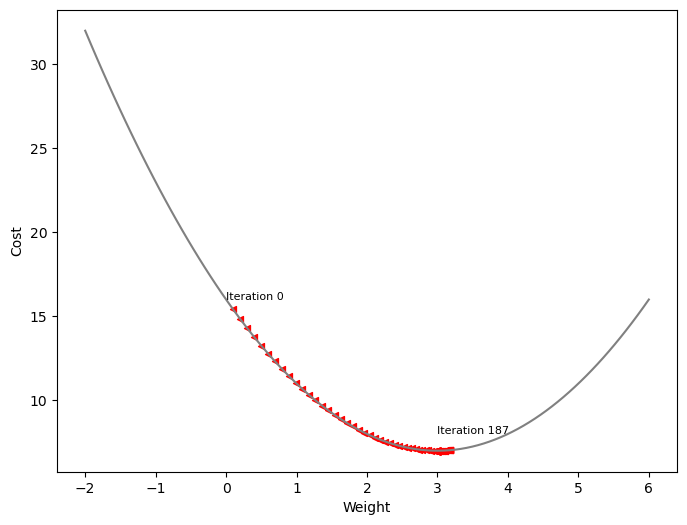

In [69]:
plot_cost_w_grad(w_his, loss_his)

As you can see from above plot, the weights updated by Adam are gradually reaches to the global minima.


## **Exercise: Comparing Optimization Methods on Fashion MNIST**


In this exercise, we will build a simple neural network model to classify Fashion MNIST images.

We will use the 2 optimizers we discussed above, with 3 different settings. These include: SGD with disabled momentum, SGD with momentum and Adam. In all three settings we will use the same base model architecture to allow for direct comparison.


In [70]:
NAMES = ["SGD", "SGD_momentum", "Adam"]

Let us start by loading and splitting our data into testing and training sets.


In [81]:
# Write your code here

# TODO: load and split data
(xtrain, ytrain), (xtest, ytest) = fashion_mnist.load_data()

In [82]:
xtrain.shape

(60000, 28, 28)

Now we will reshape our `xtrain` and `xtest` such that they're in the shape `(len(xtrain), -1)` and `(len(xtest), -1)`, respectively. We will also convert our target labels to categorical values using `to_categorical()`


In [83]:
# Write your code here

# TODO: reshape xtrain and xtest
xtrain = np.reshape(xtrain, (len(xtrain), -1))
xtest = np.reshape(xtest, (len(xtest), -1))

# TODO: convert ytrain, ytest to categorical
ytrain = to_categorical(ytrain)
ytest = to_categorical(ytest)

In [84]:
xtrain.shape

(60000, 784)

In the next step, we will perform basic normalization. We will also carve out a small validation set out of our original training dataset.  


In [75]:
# normalization
xtrain = np.apply_along_axis(lambda x: x / 255, 1, xtrain)
xtest = np.apply_along_axis(lambda x: x / 255, 1, xtest)

# validation set
index = 50000
xval, yval = xtrain[index:], ytrain[index:]
xtrain, ytrain = xtrain[:index], ytrain[:index]
xtrain.shape, xval.shape, xtest.shape

((50000, 784), (10000, 784), (10000, 784))

In [ ]:
xtrain.shape[1:]  # input shape for the first layer of the model

(784,)

`(784,)` means is 1-Dimensional (a flat 1D array). and `len((784,)) = 1`

Note: `(784, 1)` means the data is 2-Dimensional (a table with 784 rows and 1 column).

#### **General Rule for Choosing `input_shape`**

The fundamental rule for choosing `input_shape` in Keras is: **Look at the dimensions of a single, individual data sample, ignoring the total number of rows (samples) in your dataset.**

Mathematically, if your complete training array has the shape:

$$\text{Dataset Shape} = (\text{Total Samples}, \text{Dimension}_1, \text{Dimension}_2, \dots)$$

Your `input_shape` is simply everything that remains after dropping the `Total Samples` dimension.

**Keras Demands a Tuple for input_shape**, so the safest, industry-standard way to define this dynamically in Python—without ever hardcoding numbers—is using NumPy slicing:

```python
# Drops the first dimension (total rows) and extracts only the sample shape layout
input_shape = x_train.shape[1:]

**How to Apply the Rule Across Different Data Types**
**1. Tabular / Spreadsheet Data (1D per sample)**
*   **Your Data Structure:** Each row represents an item (e.g., a patient, a molecular compound) containing $N$ independent numerical features.
*   **Complete Dataset Shape:** `(10000, 25)` $\rightarrow$ (10,000 samples, 25 features each).
*   **The Rule Applied:** Drop the 10,000. The remaining shape is a 1-item tuple containing 25.
*   **Keras Setting:** `input_shape=(25,)` *(Don't forget the trailing comma for 1D tuples).*

**2. Sequence / Time-Series Data (2D per sample)**
*   **Your Data Structure:** Each sample tracks features recorded over a sequence of time steps (e.g., stock prices over 30 days, protein sequences).
*   **Complete Dataset Shape:** `(5000, 30, 8)` $\rightarrow$ (5,000 samples, 30 time steps, 8 distinct metrics per step).
*   **The Rule Applied:** Drop the 5,000. The remaining shape is a 2-item tuple describing the window matrix.
*   **Keras Setting:** `input_shape=(30, 8)`

**3. Image Data (3D per sample)**
*   **Your Data Structure:** A collection of images with spatial height, width, and color information.
*   **Complete Dataset Shape:** `(25000, 64, 64, 3)` $\rightarrow$ (25,000 images, 64x64 pixel resolution, 3 color channels like RGB).
*   **The Rule Applied:** Drop the 25,000. The remaining shape is a 3-item tuple describing the solid pixel array.
*   **Keras Setting:** `input_shape=(64, 64, 3)`

Let us define a simple sequential neural network model. In the cell below set the input shape of the first Dense layer to `xtrain.shape[1:]`. Finally, build the model with the same input shape.


In [ ]:
# Write your code here
model = Sequential(
    [  # TODO: input_shape =
        Dense(
            128,
            input_shape=xtrain.shape[1:],
            activation="relu",
            name="dense_1",
        ),
        Dense(64, activation="relu", name="dense_2"),
        Dropout(0.2),
        Dense(10, activation="softmax", name="dense_3"),
    ],
    name="Sequential",
)

# TODO: model.build(input_shape=)
model.build(input_shape=(None,) + xtrain.shape[1:])
model.summary()

Model: "Sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

We will be using a popular Python library called `tqdm` to keep track of the training of our 3 models. Each model will be trained for 10 epochs, and for each iteration we will save the results in separate dictionary objects.


In [77]:
# params
epochs = 10
batch_size = 64
shuffle = True

# dicts for storing results
loss = {opt: [] for opt in NAMES}
val_loss = {opt: [] for opt in NAMES}
acc = {opt: [] for opt in NAMES}
val_acc = {opt: [] for opt in NAMES}
test_acc = {}
test_loss = {}

In the cell below, define three different types of optimizers with the following settings: **(Note that this may take a while to run (10+ minutes))**
    
* SGD: lr = 0.001
* SGD: lr = 0.001, momentum = 0.9
* Adam: lr = 0.001, beta_1 = 0.9, beta_2 = 0.999 


In [78]:
# Write your code here
weights = model.get_weights().copy()

with tqdm(desc="Training", total=len(NAMES * epochs)) as pbar:
    for name in NAMES:
        optimizer = ""

        # prepare model
        model.set_weights(weights)
        if name == "SGD":
            optimizer = SGD(learning_rate=0.001)
        elif name == "SGD_momentum":
            optimizer = SGD(learning_rate=0.001, momentum=0.9)
        elif name == "Adam":
            optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
        print("Optimizer: ", name)
        model.compile(
            optimizer=optimizer,
            loss="categorical_crossentropy",
            metrics=["acc"],
        )

        # train model
        for epoch in range(epochs):
            his = model.fit(
                xtrain,
                ytrain,
                epochs=1,
                batch_size=batch_size,
                validation_data=(xval, yval),
                shuffle=shuffle,
                verbose=0,
            )

            # update dictionaries
            loss[name].append(his.history["loss"][0])
            val_loss[name].append(his.history["val_loss"][0])
            acc[name].append(his.history["acc"][0])
            val_acc[name].append(his.history["val_acc"][0])
            pbar.update(1)

        # inference
        t_loss, t_acc = model.evaluate(xtest, ytest, verbose=0)
        test_loss[name] = t_loss
        test_acc[name] = t_acc

Training:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizer:  SGD
Optimizer:  SGD_momentum
Optimizer:  Adam


Finally, let us visualize the results we saved during the training procedure.


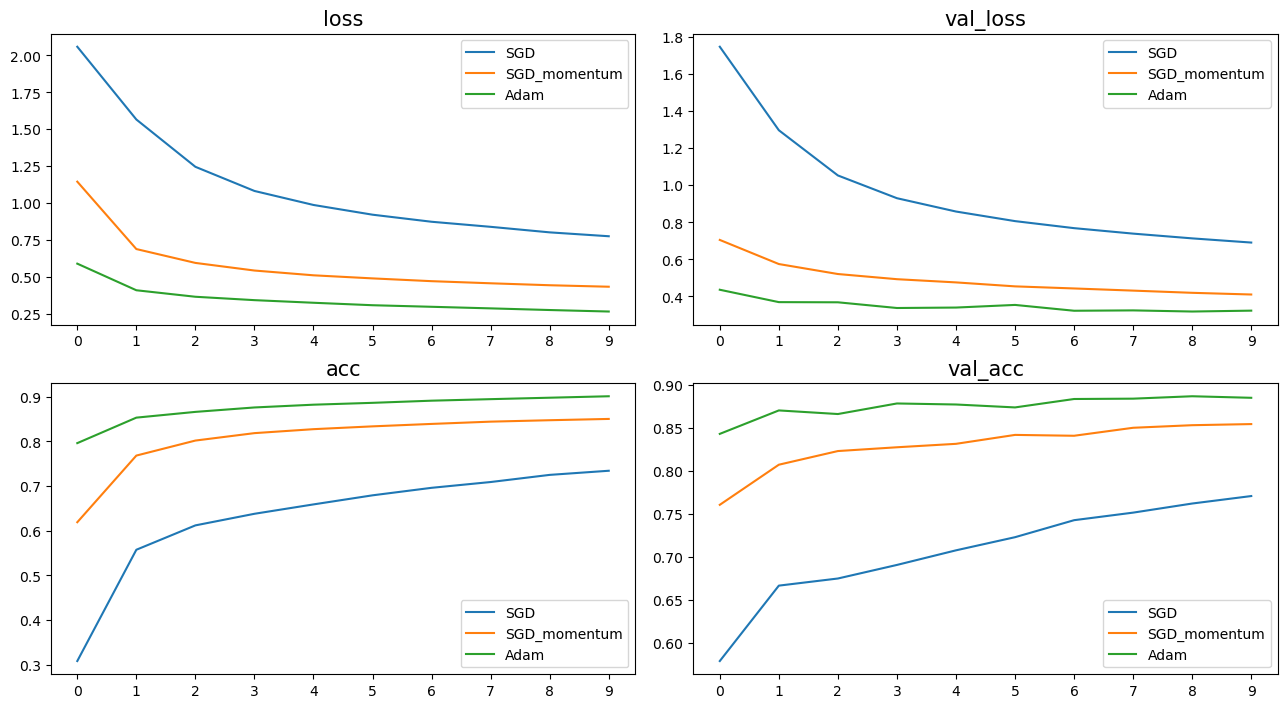

In [79]:
fig, axs = plt.subplots(2, 2, figsize=(13, 7))
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)


for index, result, title in zip(
    [[0, 0], [0, 1], [1, 0], [1, 1]],
    [loss, val_loss, acc, val_acc],
    ["loss", "val_loss", "acc", "val_acc"],
):
    i, j = index
    for name, values in result.items():
        axs[i, j].plot(values, label=name)
        axs[i, j].set_title(title, size=15)
        axs[i, j].set_xticks([e for e in range(epochs)])
        axs[i, j].legend(loc="best", prop={"size": 10})

As seen above, SGD with momentum outperforms SGD without momentum. In this case, Adam performs the best. In fact, it works well in most cases so it often set to be the default optimizer for many neural network models.


Let us look at a few images from our test dataset and see how our model classifies them.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step


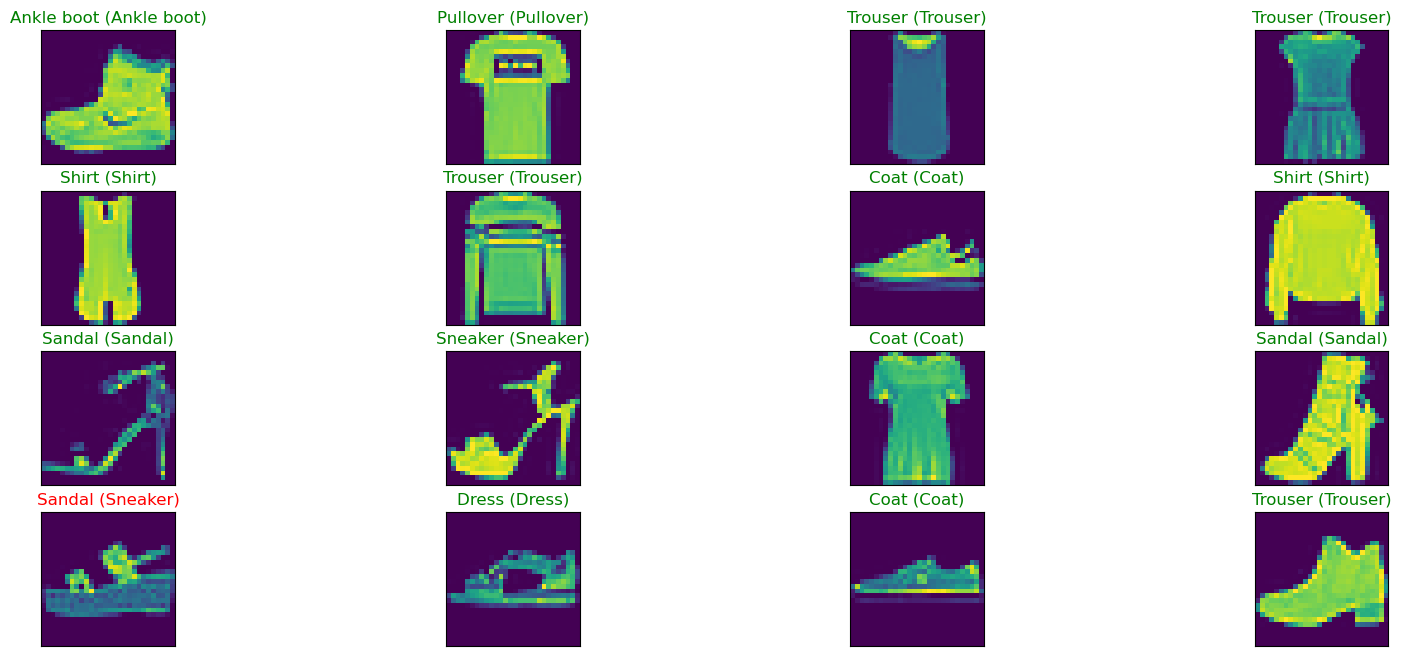

In [80]:
w, h = 28, 28
fashion_mnist_labels = [
    "T-shirt/top",  # index 0
    "Trouser",  # index 1
    "Pullover",  # index 2
    "Dress",  # index 3
    "Coat",  # index 4
    "Sandal",  # index 5
    "Shirt",  # index 6
    "Sneaker",  # index 7
    "Bag",  # index 8
    "Ankle boot",
]  # index 9

y_hat = model.predict(xtest)

figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(range(16)):

    ax = figure.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(xtrain.reshape(xtrain.shape[0], w, h, 1)[index]))
    predict_index = np.argmax(y_hat[index])
    true_index = np.argmax(ytest[index])
    ax.set_title(
        "{} ({})".format(
            fashion_mnist_labels[predict_index],
            fashion_mnist_labels[true_index],
        ),
        color=("green" if predict_index == true_index else "red"),
    )

## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01)

Su Wu

### **Other contributors**
[Kopal Garg](https://www.linkedin.com/in/gargkopal/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01) 


## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2022-06-10|1.0|Yan|Created the initial version|
|2022-06-21|1.0|Roxanne Li|Review and edit content|
|2022-08-10|1.0|Kopal Garg|Add exercise|
|2022-11-11|1.0|Kopal Garg|Review and edit content|
|2026-05-18|2.0|Su Wu|Documentation Edits|


Copyright © 2021 IBM Corporation. All rights reserved.
